# Notebook 02c — PPO-CF on `CartPole-v1`

Compare three arms from one config, changing only `ppo.pg_mode`:

| arm | `pg_mode` | what it is |
|---|---|---|
| `gae` | `gae` | plain PPO control |
| `cf` | `cf_all_action` | PPO-CF with rollout counterfactuals |
| `shuf` | `cf_shuffled` | same oracle vectors on different states |

CartPole is dense-reward and easy for PPO, so this notebook is primarily a
pipeline check for the PPO-CF training path. If CF wins, check update size before
attributing the win to counterfactual information.


---
## Knobs


In [1]:
# ----------------------------------------------------------------------------
# EDIT ME
# ----------------------------------------------------------------------------
ENV_CONFIG    = "cartpole_cf"
SEEDS         = [0, 1, 2, 3, 4]       # None -> use the config's seeds
FORCE_RETRAIN = True

RUN_ORACLE_CHECKS = True
RUN_CONTROL       = True
RUN_CF            = True
RUN_SHUFFLED      = False

ORACLE_CHECK_RUN  = "cartpole"
ORACLE_CHECK_CKPT = 0.75

OVERRIDES = {
    # "ppo.total_timesteps": 50_000,
    # "run.seeds": (0,),
    # "ppo.cf_horizon": 8,
    # "ppo.cf_subsample": 0.20,
    # "ppo.alpha_cf": 0.1,
    # "ppo.target_kl": 0.03,
}
# ----------------------------------------------------------------------------


## 0. Setup


In [2]:
%load_ext autoreload
%autoreload 2

import sys, pathlib, time

ROOT = pathlib.Path.cwd()
if not (ROOT / "config").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import make_config, seed_dir, RUNS_DIR, FIGURES_DIR
from dataio import load_trajectories, load_checkpoint, list_checkpoints
from utils.logging import read_scalars
from utils.plotting import savefig
from scripts.train import run_seeds

base = make_config(ENV_CONFIG, **OVERRIDES)
if SEEDS is not None:
    base = make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": tuple(SEEDS)})
SEEDS = tuple(base.run.seeds)
STEM = base.run.run_name

ARMS = {
    k: make_config(ENV_CONFIG, **{**OVERRIDES, "run.seeds": SEEDS,
                                  "ppo.pg_mode": m, "run.run_name": f"{STEM}_{k}"})
    for k, m in [("gae", "gae"), ("cf", "cf_all_action"), ("shuf", "cf_shuffled")]
}
FIG = FIGURES_DIR / f"nb02_{STEM}"
FIG.mkdir(parents=True, exist_ok=True)
ACTION_NAMES = ["push left", "push right"]

print(ARMS["cf"].summary())
print()
print(f"arms: {[c.run.run_name for c in ARMS.values()]}   seeds: {list(SEEDS)}")


config             cartpole_cf
env                CartPole-v1  (n_envs=16, obs_norm=running)
layouts            random every episode
total_timesteps    350,000  per seed
rollout batch      2048  (16 envs x 128 steps)
updates            170
minibatch size     256  x 4 epochs
gamma / lambda     0.99 / 0.95
lr                 0.0003  (anneal=True)
encoder            mlp  (shared=False)
entropy            fixed, coef 0.0
prob floor         0.0 -> 0.0  (0 = off)
adv norm           batch  (min_std 1e-06)
policy gradient    cf_all_action  alpha_gae=1.0 alpha_cf=0.5, Q_g horizon=32 x2 rollouts, subsample=10%, restore=exact
reward shaping     off
warm start         none
seeds              [0, 1, 2, 3, 4]
checkpoints at     ['10%', '30%', '50%', '75%', '100%']

arms: ['cartpole_gae', 'cartpole_cf', 'cartpole_shuf']   seeds: [0, 1, 2, 3, 4]


---
# 1. Test The Oracle

For CartPole, exact simulator restore is through `env.unwrapped.state`. There is
no MiniGrid fast-restore path involved.


In [3]:
from envs.env_pool import set_sim_state
from oracle.online import OnlineOracle, check_replay, check_centering, landscape_summary

if RUN_ORACLE_CHECKS:
    cfg = ARMS["cf"]
    K = 2
    sd = seed_dir(ORACLE_CHECK_RUN, SEEDS[0]) if ORACLE_CHECK_RUN else None
    traj_path = sd / "trajectories.npz" if sd else None
    if sd and traj_path.exists():
        traj = load_trajectories(traj_path)
        ckpts = list_checkpoints(sd / "checkpoints")
        if not ckpts:
            raise FileNotFoundError(f"no checkpoints found under {sd / 'checkpoints'}")
        loaded = [(p, load_checkpoint(p)) for p in ckpts]
        p_ck, ck = min(loaded, key=lambda pc: abs(pc[1].fraction - ORACLE_CHECK_CKPT))
        value_fn, probs_fn = ck.values, ck.probs
        src = f"{ORACLE_CHECK_RUN} @ {ck.fraction:.0%} ({p_ck.name})"
        N = min(600, len(traj))
        sims  = traj.sim_state[:N]
        acts  = traj.action[:N]
        rews  = traj.reward[:N]
        nsims = traj.next_sim_state[:N]
    else:
        from agents.ppo import PPOTrainer
        print(f"no completed trajectory at {traj_path}; using one live rollout for smoke-only oracle checks")
        _t = PPOTrainer(cfg, seed=SEEDS[0], progress=False)
        _t.pool.reset(); _t.collect_rollout()
        T, NE = cfg.ppo.n_steps, cfg.env.n_envs
        f = lambda a: a[:T].reshape((T * NE,) + a.shape[2:])
        sims, acts, rews, nsims = f(_t.buffer.sim_state), f(_t.buffer.actions), f(_t.buffer.rewards), f(_t.buffer.next_sim_state)
        value_fn, probs_fn = _t._values_np, _t._probs_np
        src = "fresh rollout"

    oracle = OnlineOracle(cfg.env.env_id, K, cfg.ppo.gamma, {}, cfg.env.max_episode_steps,
                          restore=cfg.ppo.cf_restore)
    print(f"oracle check source: {src}; {len(sims)} states; K={K}")


no completed trajectory at /Users/charithapalika/Desktop/Personal Projects/PPO_CF/runs/cartpole/seed_0/trajectories.npz; using one live rollout for smoke-only oracle checks
oracle check source: fresh rollout; 2048 states; K=2


## 1.1 Restore, Centering, And Landscape Shape


In [4]:
if RUN_ORACLE_CHECKS:
    rep = check_replay(oracle, sims[:400], acts[:400], rews[:400], nsims[:400])
    print(f"restore replay exact over {rep['n']} transitions")
    print(f"  max reward error {rep['max_reward_error']:.3e}")
    print(f"  max state error  {rep['max_state_error']:.3e}")

    obs0 = np.stack([set_sim_state(oracle.env, s, elapsed_steps=0) for s in sims[:300]])
    pi = probs_fn(obs0)
    a_cf, q_cf, diag = oracle.a_g(
        sims[:300], pi[:300], probs_fn, value_fn,
        horizon=cfg.ppo.cf_horizon, n_rollouts=cfg.ppo.cf_rollouts,
        bootstrap_tail=cfg.ppo.cf_bootstrap_tail, chunk=cfg.ppo.cf_branch_envs)
    c = check_centering(a_cf, pi[:300])
    s_ = landscape_summary(a_cf, q_cf, pi[:300], spread_threshold=cfg.oracle.spread_threshold)

    print()
    print("Q_g diagnostics")
    print(f"  branches that saw reward         {diag['reward_coverage']:.3f}")
    print(f"  branches terminating within H    {diag['terminated_within_horizon']:.3f}")
    print(f"  states with reward in some branch {diag['frac_states_any_reward']:.3f}")
    print()
    print("Landscape")
    print(f"  centering max |sum pi*A_CF|      {c['max_abs']:.3e}")
    print(f"  mean |A_CF|                      {s_['mean_abs_a_cf']:.4f}")
    print(f"  frac states with spread > {cfg.oracle.spread_threshold}    {s_['frac_states_with_spread']:.3f}")
    print(f"  all finite                       {s_['finite']}")
    print("  best action by A_CF:")
    for name, count in zip(ACTION_NAMES, s_["best_action_counts"]):
        print(f"    {name:10s} {count:5d}")


restore replay exact over 400 transitions
  max reward error 0.000e+00
  max state error  0.000e+00

Q_g diagnostics
  branches that saw reward         1.000
  branches terminating within H    0.889
  states with reward in some branch 1.000

Landscape
  centering max |sum pi*A_CF|      3.085e-06
  mean |A_CF|                      2.5210
  frac states with spread > 0.01    0.947
  all finite                       True
  best action by A_CF:
    push left    146
    push right   154


## 1.2 Oracle Verdict


In [5]:
if RUN_ORACLE_CHECKS:
    checks = {
        "restore/replay is exact": rep["exact"],
        "A_CF is policy-centred (max < 1e-4)": c["ok"],
        "A_CF is finite": s_["finite"],
        f"actions differ in > {cfg.oracle.min_frac_states_with_spread:.0%} of states":
            s_["frac_states_with_spread"] > cfg.oracle.min_frac_states_with_spread,
    }
    width = max(len(k) for k in checks)
    for k, v in checks.items():
        print(f"  {'PASS' if v else 'FAIL'}  {k:<{width}}")
    print()
    print("ORACLE:", "PASS -- safe to train on" if all(checks.values())
          else "FAIL -- inspect before trusting CF results")
    oracle.close()


  PASS  restore/replay is exact            
  PASS  A_CF is policy-centred (max < 1e-4)
  PASS  A_CF is finite                     
  PASS  actions differ in > 20% of states  

ORACLE: PASS -- safe to train on


---
# 2. Train Arms


In [6]:
def train_arm(key):
    c = ARMS[key]
    done = all((seed_dir(c.run.run_name, s) / "scalars.csv").exists() for s in c.run.seeds)
    if done and not FORCE_RETRAIN:
        print(f"found existing run at {RUNS_DIR / c.run.run_name} -- skipping")
        return None
    t0 = time.time()
    out = run_seeds(c)
    print()
    print(f"{key}: {(time.time() - t0) / 60:.1f} min total")
    return out

if RUN_CONTROL:
    train_arm("gae")
if RUN_CF:
    train_arm("cf")
if RUN_SHUFFLED:
    train_arm("shuf")



=== seed 0 ====================================================
  upd     5/170  step   10,240  ret  49.800  succ 0.00  sg1 0.00 sg2 0.00  ent 0.613  advstd 4.16e+00  ev  0.017  30,517 sps
  upd    10/170  step   20,480  ret 118.730  succ 0.01  sg1 0.00 sg2 0.00  ent 0.594  advstd 3.73e+00  ev  0.010  30,848 sps
  upd    15/170  step   30,720  ret 209.530  succ 0.15  sg1 0.00 sg2 0.00  ent 0.566  advstd 3.97e+00  ev  0.049  31,341 sps
  upd    20/170  step   40,960  ret 297.480  succ 0.24  sg1 0.00 sg2 0.00  ent 0.560  advstd 3.86e+00  ev  0.088  31,506 sps
  upd    25/170  step   51,200  ret 380.680  succ 0.43  sg1 0.00 sg2 0.00  ent 0.532  advstd 3.46e+00  ev  0.085  31,433 sps
  upd    30/170  step   61,440  ret 434.590  succ 0.61  sg1 0.00 sg2 0.00  ent 0.501  advstd 3.30e+00  ev  0.032  30,872 sps
  upd    35/170  step   71,680  ret 452.370  succ 0.68  sg1 0.00 sg2 0.00  ent 0.483  advstd 3.47e+00  ev  0.065  30,615 sps
  upd    40/170  step   81,920  ret 455.410  succ 0.68  sg1 

---
# 3. Compare


In [7]:
scal = {k: {s: read_scalars(seed_dir(c.run.run_name, s) / "scalars.csv")
            for s in c.run.seeds if (seed_dir(c.run.run_name, s) / "scalars.csv").exists()}
        for k, c in ARMS.items()}
scal = {k: v for k, v in scal.items() if v}

THRESH = 0.9
def frames_to(d, col="success_rate_100", thresh=THRESH):
    hit = d.loc[d[col] >= thresh, "global_step"]
    return int(hit.iloc[0]) if len(hit) else None

rows = []
for arm, per_seed in scal.items():
    for s, d in per_seed.items():
        rows.append({
            "arm": arm,
            "seed": s,
            f"frames_to_{THRESH:g}": frames_to(d),
            "final_return": round(float(d["mean_return_100"].iloc[-1]), 1),
            "final_success": round(float(d["success_rate_100"].iloc[-1]), 3),
            "best_success": round(float(d["success_rate_100"].max()), 3),
            "ev_median": round(float(d["explained_variance"].median()), 3),
            "kl_median": round(float(d["approx_kl"].median()), 4),
            "clipfrac_median": round(float(d["clipfrac"].median()), 3),
            "cf_coverage": (round(float(d["cf_reward_coverage"].mean()), 3)
                            if "cf_reward_coverage" in d else None),
            "cf_corr_gae": (round(float(d["cf_corr_gae"].mean()), 3)
                            if "cf_corr_gae" in d else None),
        })
cmp_df = pd.DataFrame(rows).sort_values(["arm", "seed"])
display(cmp_df)

print(f"median frames to success >= {THRESH:g}")
for arm, g in cmp_df.groupby("arm"):
    v = g[f"frames_to_{THRESH:g}"].dropna()
    print(f"  {arm:4s} {('%.0f' % v.median()) if len(v) else 'never':>10s}   ({len(v)}/{len(g)} seeds reached it)")


,arm,seed,frames_to_0.9,final_return,final_success,best_success,ev_median,kl_median,clipfrac_median,cf_coverage,cf_corr_gae
5,cf,0,71680.0,247.6,0.00,0.93,0.136,0.0001,0.0,1.0,0.026
6,cf,1,112640.0,500.0,1.00,1.00,0.001,0.0001,0.0,1.0,-0.003
7,cf,2,204800.0,500.0,1.00,1.00,0.008,0.0001,0.0,1.0,0.018
8,cf,3,266240.0,493.1,0.98,0.98,0.498,0.0003,0.0,1.0,0.024
9,cf,4,286720.0,500.0,1.00,1.00,0.375,0.0002,0.0,1.0,0.032
0,gae,0,NaN,247.1,0.00,0.68,0.834,0.0002,0.0,NaN,NaN
1,gae,1,225280.0,500.0,1.00,1.00,0.136,0.0001,0.0,NaN,NaN
2,gae,2,NaN,206.2,0.00,0.10,0.882,0.0002,0.0,NaN,NaN
3,gae,3,81920.0,500.0,1.00,1.00,0.001,0.0002,0.0,NaN,NaN
4,gae,4,NaN,220.5,0.09,0.09,0.883,0.0002,0.0,NaN,NaN


median frames to success >= 0.9
  cf       204800   (5/5 seeds reached it)
  gae      153600   (2/5 seeds reached it)


## 3.1 Curves And CF Health


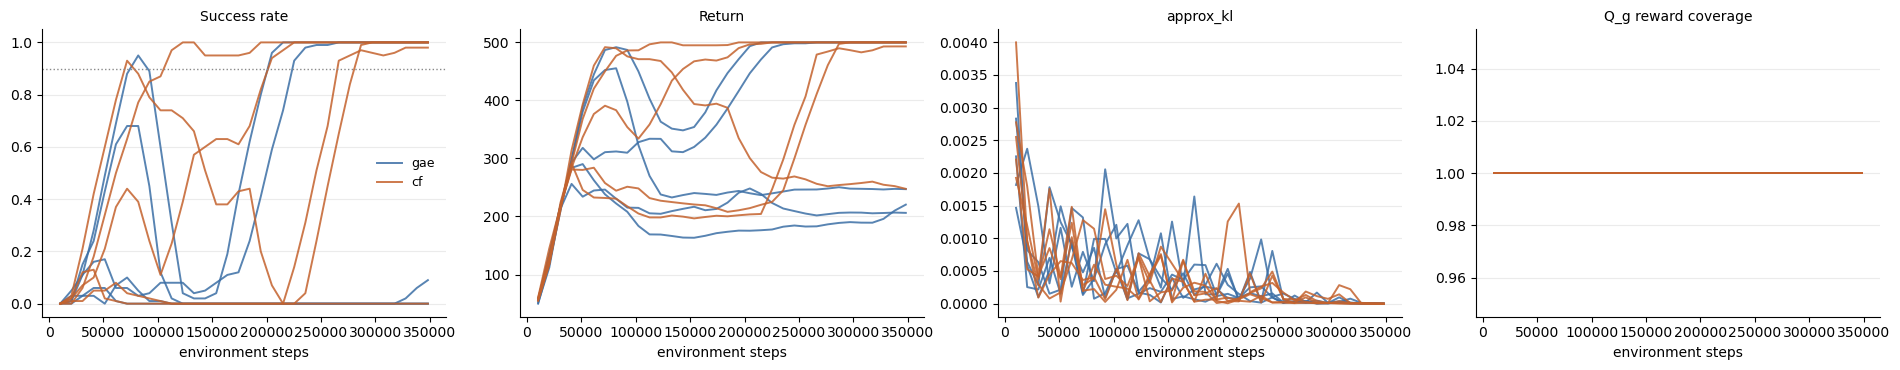


cartpole_cf  (seed 0)
  cf_centering         mean +1.432e-06  last +2.025e-06
  cf_reward_coverage   mean +1  last +1
  cf_corr_gae          mean +0.02562  last -0.1642
  cf_mean_abs          mean +0.02589  last +0.02148
  cf_n_cf_states       mean +205  last +205


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
colors = {"gae": "#3b6ea5", "cf": "#c4622d", "shuf": "#7a7a7a"}
panels = [("success_rate_100", "Success rate"),
          ("mean_return_100", "Return"),
          ("approx_kl", "approx_kl"),
          ("cf_reward_coverage", "Q_g reward coverage")]
for ax, (col, title) in zip(axes, panels):
    for arm, per_seed in scal.items():
        for i, (s, d) in enumerate(per_seed.items()):
            if col not in d.columns or not np.isfinite(d[col]).any():
                continue
            ax.plot(d["global_step"], d[col], lw=1.4, alpha=0.85, color=colors[arm],
                    label=arm if i == 0 else None)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("environment steps")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
axes[0].axhline(THRESH, color="#888", ls=":", lw=1)
axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout()
savefig(fig, FIG / "arms.png")
plt.show()

for arm in ("cf", "shuf"):
    if arm not in scal:
        continue
    seed0 = sorted(scal[arm])[0]
    d = scal[arm][seed0]
    print()
    print(f"{ARMS[arm].run.run_name}  (seed {seed0})")
    for col in ["cf_centering", "cf_reward_coverage", "cf_corr_gae", "cf_mean_abs", "cf_n_cf_states"]:
        if col not in d.columns or not np.isfinite(d[col]).any():
            print(f"  {col:20s} not logged")
            continue
        print(f"  {col:20s} mean {d[col].mean():+.4g}  last {d[col].iloc[-1]:+.4g}")


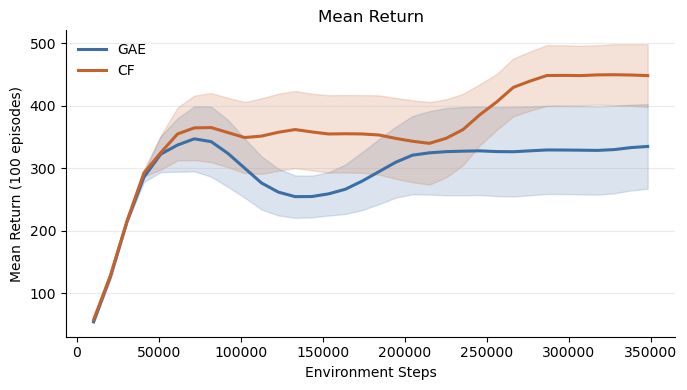

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

colors = {
    "gae": "#3b6ea5",
    "cf": "#c4622d",
}

fig, ax = plt.subplots(figsize=(7, 4))

for arm in ["gae", "cf"]:

    all_seeds = []

    for seed, d in scal[arm].items():
        temp = d[["global_step", "mean_return_100"]].copy()
        temp["seed"] = seed
        all_seeds.append(temp)

    # Combine all seeds
    combined = pd.concat(all_seeds, ignore_index=True)

    # Mean, standard deviation, and number of seeds
    stats = (
        combined
        .groupby("global_step")["mean_return_100"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # Standard error of the mean
    stats["sem"] = stats["std"] / np.sqrt(stats["count"])

    # Mean curve
    ax.plot(
        stats["global_step"],
        stats["mean"],
        lw=2.2,
        color=colors[arm],
        label=arm.upper()
    )

    # Mean ± SEM
    ax.fill_between(
        stats["global_step"],
        stats["mean"] - stats["sem"],
        stats["mean"] + stats["sem"],
        color=colors[arm],
        alpha=0.18
    )

ax.set_title("Mean Return")
ax.set_xlabel("Environment Steps")
ax.set_ylabel("Mean Return (100 episodes)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)

ax.legend(frameon=False)

fig.tight_layout()

savefig(fig, FIG / "gae_cf_mean_return_sem.png")

plt.show()

## 4. Reading The Result

CartPole should be easy for the GAE arm. Treat this as a PPO-CF plumbing check:
restore exactness, centered advantages, finite CF diagnostics, and reasonable KL.
If CF appears better but takes much larger policy steps, rerun all arms with
`ppo.target_kl: 0.03` before interpreting the comparison.
